# Connect-4 Lookahead Head-to-Head (A vs B)

Pit two **Connect4Lookahead** agents against each other.

- Choose **A** and **B** as either:
  - an integer lookahead depth (e.g., `3`, `7`, `11`)
  - or a baseline key: `"R"` (random), `"C"` (center-first), `"LEFT"` (leftmost)
- Plays **N games** with **alternating starts**.
- Reports win/loss/draw totals and per-start breakdown.


In [1]:
import random
from dataclasses import dataclass
from typing import Optional, Union, Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from C4.fast_connect4_lookahead import Connect4Lookahead


In [2]:
# =============================
# Match configuration
# =============================

# Pick either an int depth, or one of: "R", "C", "LEFT"
A_SPEC = 7
B_SPEC = 8

N_GAMES = 100
SEED = 0

# If True, prints a tiny log for the first few games
VERBOSE_FIRST_K = 0

# If True, each lookahead agent may randomize some opening replies (depends on your agent)
OPENING_RANDOM = False


In [3]:
# =============================
# Core game helpers (board is 6x7 with values {0,1,2}; top row index 0)
# =============================

ROWS, COLS = 6, 7

def legal_moves(board: np.ndarray) -> List[int]:
    """Legal columns are those where the top cell is empty."""
    top = board[0]
    return [c for c in range(COLS) if int(top[c]) == 0]

def apply_move(board: np.ndarray, col: int, player: int) -> None:
    """Drop a stone for `player` (1 or 2) into `col`. Mutates board in-place."""
    if col < 0 or col >= COLS:
        raise ValueError(f"col out of range: {col}")
    if int(board[0, col]) != 0:
        raise ValueError(f"illegal move: column {col} is full")
    for r in range(ROWS - 1, -1, -1):
        if int(board[r, col]) == 0:
            board[r, col] = int(player)
            return
    raise RuntimeError("unexpected: column reported legal but no slot found")

def board_full(board: np.ndarray) -> bool:
    return all(int(board[0, c]) != 0 for c in range(COLS))


In [4]:
# =============================
# Agent wrapper
# =============================

Spec = Union[int, str]

@dataclass
class Agent:
    name: str
    spec: Spec
    la: Optional[Connect4Lookahead] = None

    def __post_init__(self):
        if self.la is None:
            self.la = Connect4Lookahead()
        try:
            self.la.OPENING_RANDOM = bool(OPENING_RANDOM)
        except Exception:
            pass

    def choose(self, board: np.ndarray, player: int, rng: random.Random) -> int:
        legal = legal_moves(board)
        if not legal:
            return 0

        if isinstance(self.spec, str):
            k = self.spec.strip().upper()
            if k in ("R", "RANDOM"):
                return int(rng.choice(legal))
            if k in ("C", "CENTER", "CENTRE"):
                for c in (3, 4, 2, 5, 1, 6, 0):
                    if c in legal:
                        return int(c)
                return int(legal[0])
            if k in ("LEFT", "L", "LEFTMOST"):
                return int(min(legal))
            if k.startswith('L') and k[1:].isdigit():
                depth = int(k[1:])
                a = int(self.la.n_step_lookahead(board, player=player, depth=depth))
                return a if a in legal else int(rng.choice(legal))
            raise ValueError(f"Unknown spec string: {self.spec!r}")

        depth = int(self.spec)
        if depth <= 0:
            return int(rng.choice(legal))
        a = int(self.la.n_step_lookahead(board, player=player, depth=depth))
        return a if a in legal else int(rng.choice(legal))


In [5]:
# =============================
# Match loop (alternate starts)
# =============================

def play_one_game(A: Agent, B: Agent, A_starts: bool, rng: random.Random, max_plies: int = 42) -> Tuple[int, int]:
    """Return (result, plies). result: +1 if A wins, -1 if B wins, 0 draw."""
    board = np.zeros((ROWS, COLS), dtype=np.int8)

    A_mark = 1 if A_starts else 2
    B_mark = 2 if A_starts else 1
    cur = 1

    la_for_check = A.la

    for ply in range(1, max_plies + 1):
        if cur == A_mark:
            action = A.choose(board, player=A_mark, rng=rng)
            apply_move(board, action, A_mark)
            if la_for_check.has_four(board, player=A_mark):
                return (+1, ply)
        else:
            action = B.choose(board, player=B_mark, rng=rng)
            apply_move(board, action, B_mark)
            if la_for_check.has_four(board, player=B_mark):
                return (-1, ply)

        if board_full(board):
            return (0, ply)

        cur = 2 if cur == 1 else 1

    return (0, max_plies)


def run_match(A_spec: Spec, B_spec: Spec, n_games: int = 200, seed: int = 0, verbose_first_k: int = 0) -> Dict[str, float]:
    rng = random.Random(int(seed))
    A = Agent(name=f"A({A_spec})", spec=A_spec)
    B = Agent(name=f"B({B_spec})", spec=B_spec)

    a_wins = b_wins = draws = 0
    a_wins_first = a_wins_second = 0
    b_wins_first = b_wins_second = 0
    draw_first = draw_second = 0
    plies_list: List[int] = []

    for g in tqdm(range(n_games), desc="Games", leave=True):
        A_starts = (g % 2 == 0)
        res, plies = play_one_game(A, B, A_starts=A_starts, rng=rng)
        plies_list.append(int(plies))

        if res > 0:
            a_wins += 1
            if A_starts:
                a_wins_first += 1
            else:
                a_wins_second += 1
        elif res < 0:
            b_wins += 1
            if A_starts:
                b_wins_second += 1
            else:
                b_wins_first += 1
        else:
            draws += 1
            if A_starts:
                draw_first += 1
            else:
                draw_second += 1

        if verbose_first_k and g < verbose_first_k:
            starter = "A" if A_starts else "B"
            print(f"Game {g+1}/{n_games} starter={starter} result={res:+d} plies={plies}")

    score_A = (a_wins + 0.5 * draws) / float(n_games)
    score_B = (b_wins + 0.5 * draws) / float(n_games)

    return {
        "A_spec": str(A_spec),
        "B_spec": str(B_spec),
        "n_games": float(n_games),
        "A_wins": float(a_wins),
        "B_wins": float(b_wins),
        "draws": float(draws),
        "A_score": float(score_A),
        "B_score": float(score_B),
        "A_wins_as_first": float(a_wins_first),
        "A_wins_as_second": float(a_wins_second),
        "B_wins_as_first": float(b_wins_first),
        "B_wins_as_second": float(b_wins_second),
        "draws_when_A_first": float(draw_first),
        "draws_when_A_second": float(draw_second),
        "mean_plies": float(np.mean(plies_list)) if plies_list else 0.0,
    }


In [6]:
%%time
# Run the match
results = run_match(A_SPEC, B_SPEC, n_games=N_GAMES, seed=SEED, verbose_first_k=VERBOSE_FIRST_K)
results


Games:   0%|          | 0/100 [00:00<?, ?it/s]

CPU times: total: 33 s
Wall time: 33.3 s


{'A_spec': '7',
 'B_spec': '8',
 'n_games': 100.0,
 'A_wins': 50.0,
 'B_wins': 50.0,
 'draws': 0.0,
 'A_score': 0.5,
 'B_score': 0.5,
 'A_wins_as_first': 50.0,
 'A_wins_as_second': 0.0,
 'B_wins_as_first': 50.0,
 'B_wins_as_second': 0.0,
 'draws_when_A_first': 0.0,
 'draws_when_A_second': 0.0,
 'mean_plies': 37.0}

In [7]:
# Nicely formatted summary
print(f"A={results['A_spec']} vs B={results['B_spec']} | games={int(results['n_games'])}")
print(f"A wins: {int(results['A_wins'])} | B wins: {int(results['B_wins'])} | draws: {int(results['draws'])}")
print(f"A score: {results['A_score']:.3f} | B score: {results['B_score']:.3f}")
print()
print(f"A wins as first : {int(results['A_wins_as_first'])}")
print(f"A wins as second: {int(results['A_wins_as_second'])}")
print(f"B wins as first : {int(results['B_wins_as_first'])}")
print(f"B wins as second: {int(results['B_wins_as_second'])}")
print(f"mean plies: {results['mean_plies']:.1f}")


A=7 vs B=8 | games=100
A wins: 50 | B wins: 50 | draws: 0
A score: 0.500 | B score: 0.500

A wins as first : 50
A wins as second: 0
B wins as first : 50
B wins as second: 0
mean plies: 37.0


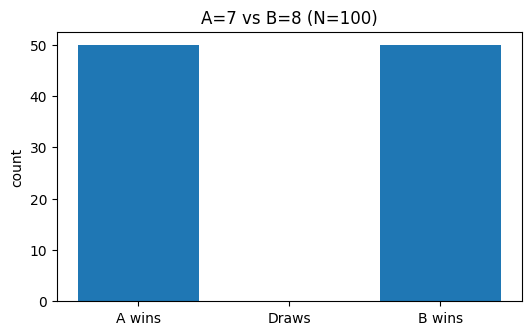

In [8]:
# Bar plot
labels = ['A wins', 'Draws', 'B wins']
vals = [results['A_wins'], results['draws'], results['B_wins']]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(labels, vals)
ax.set_title(f"A={results['A_spec']} vs B={results['B_spec']} (N={int(results['n_games'])})")
ax.set_ylabel('count')
plt.show()
